# Experiment 06 – Regression Analysis

## Aim

To develop regression models for predicting a continuous variable using the Pima Indians Diabetes Dataset and evaluate their performance using appropriate statistical metrics.

## Objectives

1. To develop regression models to predict a continuous health-related variable from medical attributes.
2. To evaluate and interpret the performance of regression models using appropriate statistical measures.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
sns.set_theme(style="whitegrid")

In [2]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("diabetes.csv")
print("Dataset loaded successfully.")
display(df.head())

Saving diabetes.csv to diabetes.csv
Dataset loaded successfully.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [3]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (768, 9)

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


## Data Preprocessing

In [4]:
medical_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]
df_processed = df.copy()
df_processed[medical_columns] = (
    df_processed[medical_columns].replace(0, np.nan)
)
for column in medical_columns:
    df_processed[column] = df_processed[column].fillna(
        df_processed[column].median()
    )
print("Missing values after preprocessing:")
print(df_processed.isnull().sum())

Missing values after preprocessing:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## Feature and Target Selection

In [5]:
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "DiabetesPedigreeFunction",
    "Age"
]
X = df_processed[features]
y = df_processed["BMI"]
print("Features:")
display(X.head())
print("\nTarget:")
display(y.head())

Features:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age
0,6,148,72.0,35,169.5,0.627,50
1,1,85,66.0,29,102.5,0.351,31
2,8,183,64.0,32,169.5,0.672,32
3,1,89,66.0,23,94.0,0.167,21
4,0,137,40.0,35,168.0,2.288,33



Target:


,BMI
0,33.6
1,26.6
2,23.3
3,28.1
4,43.1


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 614
Testing samples: 154


## Linear Regression

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [8]:
y_pred = model.predict(X_test)
prediction_comparison = pd.DataFrame({
    "Actual BMI": y_test.values,
    "Predicted BMI": y_pred
})
display(prediction_comparison.head(10))

,Actual BMI,Predicted BMI
0,34.0,31.511995
1,35.7,34.163190
2,30.8,30.727487
3,24.6,32.358190
4,29.9,31.627665
5,37.7,31.497014
6,20.4,24.316622
7,33.8,30.668978
8,31.3,32.381798
9,33.7,29.173229


## Regression Performance Metrics

In [9]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 4.3794
Mean Squared Error (MSE): 33.5038
Root Mean Squared Error (RMSE): 5.7883
R² Score: 0.2367


In [10]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})
display(coefficients)
print(f"Intercept: {model.intercept_:.4f}")

,Feature,Coefficient
0,Pregnancies,-0.001598
1,Glucose,0.019658
2,BloodPressure,0.111224
3,SkinThickness,0.429735
4,Insulin,0.007411
5,DiabetesPedigreeFunction,1.506368
6,Age,-0.090082


Intercept: 10.7806


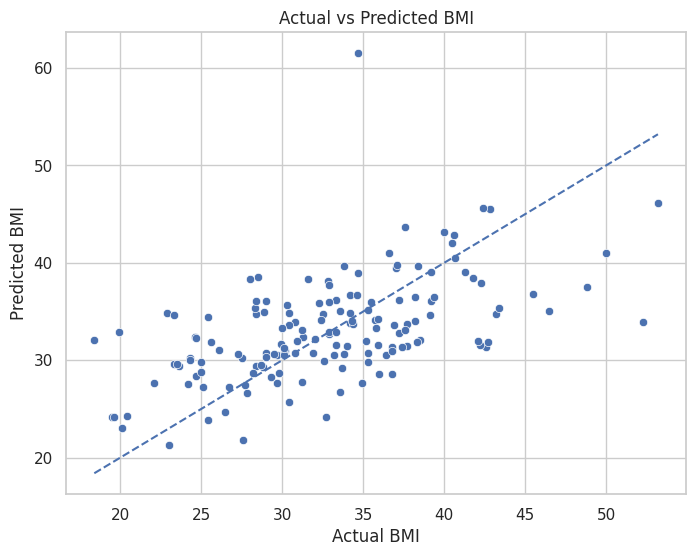

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=y_test,
    y=y_pred
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.title("Actual vs Predicted BMI")
plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.show()

## Residual Analysis

In [12]:
residuals = y_test - y_pred
residual_data = pd.DataFrame({
    "Actual BMI": y_test.values,
    "Predicted BMI": y_pred,
    "Residual": residuals.values
})
display(residual_data.head(10))

,Actual BMI,Predicted BMI,Residual
0,34.0,31.511995,2.488005
1,35.7,34.163190,1.536810
2,30.8,30.727487,0.072513
3,24.6,32.358190,-7.758190
4,29.9,31.627665,-1.727665
5,37.7,31.497014,6.202986
6,20.4,24.316622,-3.916622
7,33.8,30.668978,3.131022
8,31.3,32.381798,-1.081798
9,33.7,29.173229,4.526771


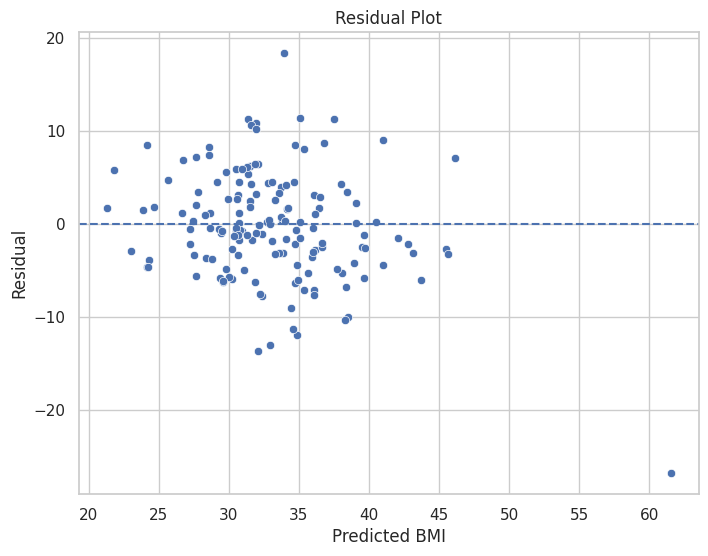

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=y_pred,
    y=residuals
)
plt.axhline(
    0,
    linestyle="--"
)
plt.title("Residual Plot")
plt.xlabel("Predicted BMI")
plt.ylabel("Residual")
plt.show()

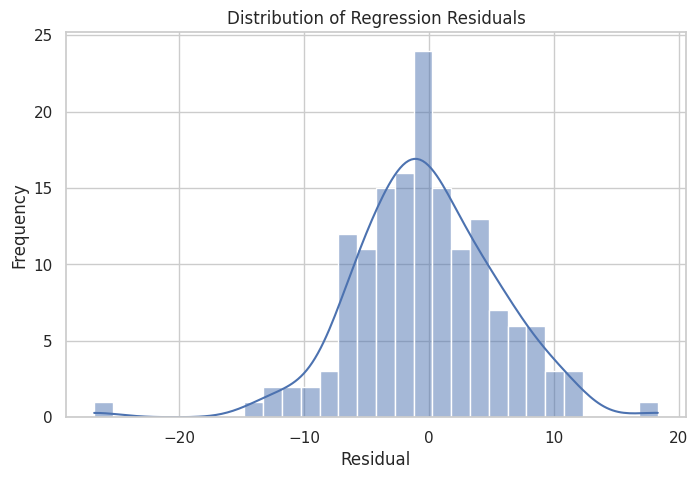

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(
    residuals,
    bins=30,
    kde=True
)
plt.title("Distribution of Regression Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

## Conclusion

A multiple linear regression model was developed to predict BMI using medical attributes from the Pima Indians Diabetes Dataset. The model was evaluated using MAE, MSE, RMSE, and R². Actual and predicted BMI values were compared, and residual analysis was performed to examine the model's prediction errors and identify possible patterns or limitations.